# Part 1: Clustering — Farthest First & K-Means++

**Dataset:** UCI Spambase — 4601 points, 57 features   
**Algorithms Implemented:**
1. `readVectorsSeq(filename)` — Load dataset
2. `kcenter(P, k)` — Farthest-First Traversal (k-center clustering)
3. `kmeansPP(P, k)` — K-Means++ initialization + Lloyd's iterations
4. `kmeansObj(P, C)` — K-Means objective (average squared distance)


## 1. Imports and Setup

In [ ]:
import numpy as np
import time
import random
from typing import List, Tuple

# PySpark imports
from pyspark.sql import SparkSession
from pyspark.mllib.linalg import Vectors, Vector

# Initialize Spark Session
spark = SparkSession.builder \
    .appName("Clustering_SpamBase") \
    .master("local[*]") \
    .getOrCreate()

sc = spark.sparkContext
sc.setLogLevel("ERROR")  # Suppress verbose Spark logs

print("Spark version:", spark.version)
print("SparkContext:", sc)

Spark version: 4.0.2
SparkContext: <SparkContext master=local[*] appName=Clustering_SpamBase>


## 2. Function 1 — `readVectorsSeq(filename)`

Reads the dataset file and converts each line into a `pyspark.mllib.linalg.Vector`.  
**Note:** The last column (index 57) is the spam/ham label — we **exclude** it from feature vectors since we are doing unsupervised clustering.

In [ ]:
def readVectorsSeq(filename: str) -> List[Vector]:
    points = []
    with open(filename, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            # Parse comma-separated values into floats
            values = list(map(float, line.split(',')))
            # Exclude the last column (class label)
            features = values[:-1]
            # Convert to Spark dense Vector
            points.append(Vectors.dense(features))
    return points


# Helper: squared Euclidean distance between two Spark Vectors
def sqdist(a: Vector, b: Vector) -> float:
    """Computes the squared L2 distance between two Spark Vectors."""
    return Vectors.squared_distance(a, b)


# Load the dataset
DATA_PATH = 'spambase.data'

P = readVectorsSeq(DATA_PATH)
print(f"Loaded {len(P)} points, each with {len(P[0])} dimensions.")

Loaded 4601 points, each with 57 dimensions.


## 3. Function 2 — `kcenter(P, k)` : Farthest-First Traversal

**Algorithm (Gonzalez's Greedy):**
1. Pick the first center arbitrarily (we pick index 0).
2. Maintain an array `min_dists[i]` = squared distance from point `i` to its closest chosen center.
3. At each step, select the point with the **maximum** `min_dists` value as the next center.
4. Update `min_dists` for all points using the newly added center.

**Complexity:** O(|P| × k) — each of the k iterations scans all |P| points once.

**Approximation guarantee:** 2-approximation of the optimal k-center solution.

In [ ]:
def kcenter(P: List[Vector], k: int) -> List[Vector]:
    """
    Farthest-First Traversal algorithm for k-center clustering
    Greedily selects k centers by always choosing the point
    that is farthest from the already-chosen set of centers.
    This gives a 2-approximation to the optimal k-center problem.
    """
    n = len(P)
    assert k <= n, "k cannot be larger than the number of points."

    # Step 1: Start with the first point as the initial center (arbitrary choice)
    centers = [P[0]]

    # Step 2: Initialize min_dists — distance of each point to its nearest center
    # Initially, only one center (P[0]), so distance is dist(P[i], P[0]) for all i
    min_dists = [sqdist(p, P[0]) for p in P]

    # Step 3: Iteratively pick the farthest point as the next center
    for _ in range(k - 1):
        # The next center is the point with maximum distance to current centers
        next_center_idx = max(range(n), key=lambda i: min_dists[i])
        next_center = P[next_center_idx]
        centers.append(next_center)

        # Update min_dists using the newly added center — O(|P|) per iteration
        for i in range(n):
            d = sqdist(P[i], next_center)
            if d < min_dists[i]:
                min_dists[i] = d

    return centers

## 4. Function 3 — `kmeansPP(P, k)` : K-Means++ Initialization



In [ ]:
def kmeansPP(P: List[Vector], k: int, n_iter: int = 20, seed: int = 42) -> List[Vector]:
    """
    K-Means++ initialization followed by Lloyd's iterations.

    Phase 1 — K-Means++ seeding (D² sampling):
        Selects k initial centers using D² probability weighting,
        which gives an O(log k)-approximation guarantee in expectation.

    Phase 2 — Lloyd's iterations:
        Refines centers by iterating assign-then-recompute.
        Each iteration is O(|P| × k); runs `n_iter` times.

    """
    rng = random.Random(seed)
    n = len(P)

    # Phase 1: K-Means++ Seeding

    # Step 1: Pick first center uniformly at random
    first_idx = rng.randint(0, n - 1)
    centers = [P[first_idx]]

    # Step 2: Initialize min_dists from each point to the first center
    min_dists = [sqdist(p, centers[0]) for p in P]  # O(|P|)

    # Step 3: D² sampling pick remaining k-1 centers
    for _ in range(k - 1):
        total = sum(min_dists)  # Sum of squared distances

        # Sample index proportional to min_dists (D² weighting)
        r = rng.uniform(0, total)
        cumulative = 0.0
        chosen_idx = 0
        for i, d in enumerate(min_dists):  # O(|P|)
            cumulative += d
            if cumulative >= r:
                chosen_idx = i
                break

        new_center = P[chosen_idx]
        centers.append(new_center)

        # Update min_dists with the new center — O(|P|)
        for i in range(n):
            d = sqdist(P[i], new_center)
            if d < min_dists[i]:
                min_dists[i] = d

    # Phase 2: Lloyd's Iterations (Refinement)
    # Convert centers and points to numpy for efficient arithmetic
    np_points = np.array([p.toArray() for p in P])          # (n, d)
    np_centers = np.array([c.toArray() for c in centers])   # (k, d)

    for iteration in range(n_iter):
        # Assignment step: assign each point to its nearest center
        # Broadcasting: (n,1,d) - (1,k,d) => (n,k,d) => sum over d => (n,k)
        diffs = np_points[:, np.newaxis, :] - np_centers[np.newaxis, :, :]
        sq_dists = np.sum(diffs ** 2, axis=2)          # (n, k)
        assignments = np.argmin(sq_dists, axis=1)      # (n,)

        # Update step: recompute centers as cluster means
        new_centers = np.zeros_like(np_centers)
        for j in range(k):
            members = np_points[assignments == j]
            if len(members) > 0:
                new_centers[j] = members.mean(axis=0)
            else:
                # Empty cluster: reinitialize to a random point
                new_centers[j] = np_points[rng.randint(0, n - 1)]

        # Convergence check
        if np.allclose(np_centers, new_centers, atol=1e-6):
            print(f"  [kmeansPP] Converged at iteration {iteration + 1}")
            break
        np_centers = new_centers

    # Convert back to Spark Vectors
    return [Vectors.dense(c) for c in np_centers]

## 5. Function 4 — `kmeansObj(P, C)` : K-Means Objective

Computes the **average squared distance** of each point to its nearest center — the standard K-Means objective function divided by the number of points.

In [ ]:
def kmeansObj(P: List[Vector], C: List[Vector]) -> float:
    np_points  = np.array([p.toArray() for p in P])  # (n, d)
    np_centers = np.array([c.toArray() for c in C])  # (k, d)

    # Compute squared distances from every point to every center: (n, k)
    diffs    = np_points[:, np.newaxis, :] - np_centers[np.newaxis, :, :]
    sq_dists = np.sum(diffs ** 2, axis=2)          # (n, k)

    # For each point, take distance to its nearest center
    min_sq_dists = np.min(sq_dists, axis=1)        # (n,)

    # Return the average
    return float(np.mean(min_sq_dists))

## 6. Main Program — Running All Three Experiments


In [ ]:
# Parameters
k  = 10   # Number of final clusters
k1 = 50   # Larger coreset size for the third experiment (k < k1)

print("=" * 65)
print(f" PART 1 CLUSTERING  |  k = {k}  |  k1 = {k1}  |  n = {len(P)} points")
print("=" * 65)

# Experiment 1: kcenter(P, k)
print("\n[Experiment 1] Farthest-First Traversal: kcenter(P, k)")
print("-" * 55)
t_start = time.time()
C_kcenter = kcenter(P, k)
t_elapsed = time.time() - t_start
print(f"  Running time of kcenter(P, {k}): {t_elapsed:.4f} seconds")
print(f"  Number of centers returned    : {len(C_kcenter)}")

# Experiment 2: kmeansPP(P, k) then kmeansObj(P, C)
print(f"\n[Experiment 2] K-Means++ on full dataset: kmeansPP(P, {k})")
print("-" * 55)
t_start = time.time()
C_kmeanspp = kmeansPP(P, k)
t_elapsed = time.time() - t_start
print(f"  Running time of kmeansPP(P, {k}): {t_elapsed:.4f} seconds")

obj2 = kmeansObj(P, C_kmeanspp)
print(f"  kmeansObj(P, C) [KMeans++ on full data]: {obj2:.4f}")

# Experiment 3: kcenter(P, k1) → kmeansPP(X, k) → kmeansObj(P, C)
print(f"\n[Experiment 3] Coreset approach: kcenter(P, {k1}) → kmeansPP(X, {k})")
print("-" * 55)
print(f"  Step 3a: Running kcenter(P, {k1}) to build coreset X...")
t_start = time.time()
X = kcenter(P, k1)          # Build a coreset of k1 points using kcenter
t_elapsed_kc = time.time() - t_start
print(f"  Running time of kcenter(P, {k1}): {t_elapsed_kc:.4f} seconds")
print(f"  Coreset size: {len(X)} points")

print(f"  Step 3b: Running kmeansPP(X, {k}) on the coreset...")
t_start = time.time()
C_coreset = kmeansPP(X, k)  # Run kmeans++ on the small coreset
t_elapsed_kpp = time.time() - t_start
print(f"  Running time of kmeansPP(X, {k}): {t_elapsed_kpp:.4f} seconds")

obj3 = kmeansObj(P, C_coreset)
print(f"  kmeansObj(P, C) [Coreset approach]: {obj3:.4f}")

# Summary
print("\n" + "=" * 65)
print(" RESULTS SUMMARY")
print("=" * 65)
print(f"  Experiment 2 — KMeans++ on full data (k={k})   : obj = {obj2:.4f}")
print(f"  Experiment 3 — Coreset k1={k1} → KMeans++ (k={k}): obj = {obj3:.4f}")
better = "Experiment 3 (coreset)" if obj3 < obj2 else "Experiment 2 (direct KMeans++)"
print(f"  Better objective achieved by: {better}")
print("=" * 65)

 PART 1 CLUSTERING  |  k = 10  |  k1 = 50  |  n = 4601 points

[Experiment 1] Farthest-First Traversal: kcenter(P, k)
-------------------------------------------------------
  Running time of kcenter(P, 10): 0.1693 seconds
  Number of centers returned    : 10

[Experiment 2] K-Means++ on full dataset: kmeansPP(P, 10)
-------------------------------------------------------
  [kmeansPP] Converged at iteration 18
  Running time of kmeansPP(P, 10): 0.3503 seconds
  kmeansObj(P, C) [KMeans++ on full data]: 17037.6443

[Experiment 3] Coreset approach: kcenter(P, 50) → kmeansPP(X, 10)
-------------------------------------------------------
  Step 3a: Running kcenter(P, 50) to build coreset X...
  Running time of kcenter(P, 50): 0.7930 seconds
  Coreset size: 50 points
  Step 3b: Running kmeansPP(X, 10) on the coreset...
  [kmeansPP] Converged at iteration 6
  Running time of kmeansPP(X, 10): 0.0045 seconds
  kmeansObj(P, C) [Coreset approach]: 259395.8745

 RESULTS SUMMARY
  Experiment 2 — KM

## 7. Varying k and k1 — Analysis

We vary `k` to study how the objective changes, and compare all three methods.

   k    k1     KMeans++ Obj      Coreset Obj
--------------------------------------------
  [kmeansPP] Converged at iteration 6
  [kmeansPP] Converged at iteration 2
   2    10      205059.7227     6883511.3381
  [kmeansPP] Converged at iteration 12
  [kmeansPP] Converged at iteration 6
   5    25       56026.2064     3067223.9318
  [kmeansPP] Converged at iteration 18
  [kmeansPP] Converged at iteration 6
  10    50       17037.6443      259395.8745
  [kmeansPP] Converged at iteration 4
  15    75        9424.6293       98347.3051
  [kmeansPP] Converged at iteration 19
  [kmeansPP] Converged at iteration 5
  20   100        5646.7394       70173.7911


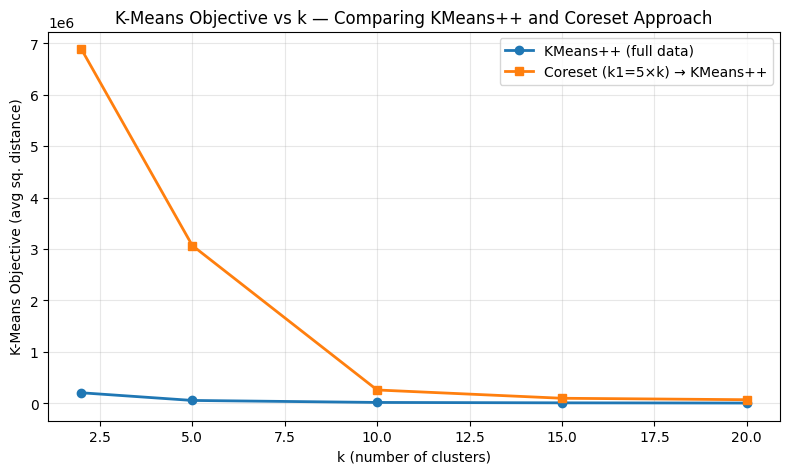

Plot saved as clustering_comparison.png


In [ ]:
import matplotlib.pyplot as plt

k_values  = [2, 5, 10, 15, 20]
k1_factor = 5   # k1 = k1_factor × k

results_kpp     = []  # Exp 2 objective
results_coreset = []  # Exp 3 objective

print(f"{'k':>4}  {'k1':>4}  {'KMeans++ Obj':>15}  {'Coreset Obj':>15}")
print("-" * 44)

for k_val in k_values:
    k1_val = k1_factor * k_val

    # Experiment 2
    C2   = kmeansPP(P, k_val)
    obj2 = kmeansObj(P, C2)

    # Experiment 3
    X    = kcenter(P, k1_val)
    C3   = kmeansPP(X, k_val)
    obj3 = kmeansObj(P, C3)

    results_kpp.append(obj2)
    results_coreset.append(obj3)
    print(f"{k_val:>4}  {k1_val:>4}  {obj2:>15.4f}  {obj3:>15.4f}")

# Plot
plt.figure(figsize=(8, 5))
plt.plot(k_values, results_kpp,     marker='o', label='KMeans++ (full data)', linewidth=2)
plt.plot(k_values, results_coreset, marker='s', label=f'Coreset (k1={k1_factor}×k) → KMeans++', linewidth=2)
plt.xlabel('k (number of clusters)')
plt.ylabel('K-Means Objective (avg sq. distance)')
plt.title('K-Means Objective vs k — Comparing KMeans++ and Coreset Approach')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('clustering_comparison.png', dpi=150)
plt.show()
print("Plot saved as clustering_comparison.png")

## 8. Spark RDD Version (Scalable)

The assignment requires Spark-runnable functions. Here we can demonstrate how
the objective computation can be parallelized using Spark RDDs — essential
for very large datasets that don't fit in memory.

In [ ]:
def kmeansObj_spark(P: List[Vector], C: List[Vector]) -> float:

    # Broadcast centers to all workers
    centers_broadcast = sc.broadcast(C)

    # Parallelize the point set as an RDD
    rdd = sc.parallelize(P)

    def min_sq_dist(point):
        """Compute minimum squared distance from a point to any center."""
        centers = centers_broadcast.value
        return min(Vectors.squared_distance(point, c) for c in centers)

    # Map: each point → min sq distance; Reduce: sum; then divide by |P|
    total = rdd.map(min_sq_dist).sum()
    return total / len(P)


# Verify Spark version matches NumPy version
print("Verifying Spark RDD objective matches NumPy objective...")

# Use the kmeans++ centers from Experiment 2 (k=10)
C_kmeanspp = kmeansPP(P, k=10)

obj_numpy = kmeansObj(P, C_kmeanspp)
obj_spark = kmeansObj_spark(P, C_kmeanspp)

print(f"  NumPy objective  : {obj_numpy:.6f}")
print(f"  Spark objective  : {obj_spark:.6f}")
print(f"  Match (atol=1e-4): {abs(obj_numpy - obj_spark) < 1e-4}")

Verifying Spark RDD objective matches NumPy objective...
  [kmeansPP] Converged at iteration 18
  NumPy objective  : 17037.644322
  Spark objective  : 17037.644322
  Match (atol=1e-4): True


In [ ]:
# Stop the Spark session when done
spark.stop()
print("Spark session stopped.")

Spark session stopped.
